# Step 1: 
## Short Term Fourier Transform (STFT): $ X[K] = \sum_{n=0}^{N-1} X[n] w[n] e^{-j2\pi \frac{n}{N}} $

# Step 2:
## Power Spectrum (Magnitude square): $ P[k] = | X[k] |^2 $

# Step 3:
## Energy at each mel-band: $ E_m = \sum_{k=0}^{K-1} P[k] H_m[k] $

# Step 4:
## Logarithmic human energy times discrete Cosine transform (DCT): $ C_n = \sum_{m=0}^{M-1} \log{E_m} \times \cos{\pi \frac{n(m+0.5)}{M}} $

In [1]:
import numpy as np

In [5]:
def mfcc(x, sr, n_mfcc=13):

    # Step 1

    X = np.fft.rfft(x)

    # Step 2
    power = np.abs(X)**2

    # Step 3: Simple mel filterbank (triangular, 4 bands for demo)

    n_bands = 4
    
    mel_bands = np.zeros((n_bands, len(power)))

    for i in range(n_bands):

        center = int(len(power) * (i + 1) / (n_bands + 1))

        left = max(0, center - 5)

        right = min(len(power), center + 5)

        mel_bands[i, left:center] = np.linspace(0, 1, center-left)

        mel_bands[i, center:right] = np.linspace(1, 0, right-center)

    # Step 4: Mel energies
    mel_energies = np.dot(mel_bands, power)
    
    log_mel = np.log(mel_energies + 1e-10)

    # Step 5: DCT

    M = n_bands

    mfccs = []

    for n in range(n_mfcc):
        coeffs = np.cos(np.pi * n * (np.arange(M) + 0.5) / M)
        mfccs.append(np.sum(log_mel * coeffs))
    return np.array(mfccs)
    
    
    

        

        
    

In [6]:
# Example
sr = 16000
t = np.linspace(0, 0.5, int(sr * 0.5))
x = np.sin(2*np.pi*200*t)
print(mfcc(x, sr, n_mfcc=4))

[-15.48025397   2.35140217   0.69670117   0.27756558]


In [13]:
import librosa

import matplotlib.pyplot as plt

In [8]:
sr = 16000

audio, sr = librosa.load("test_healthy_voice.wav", sr=sr, mono= True)


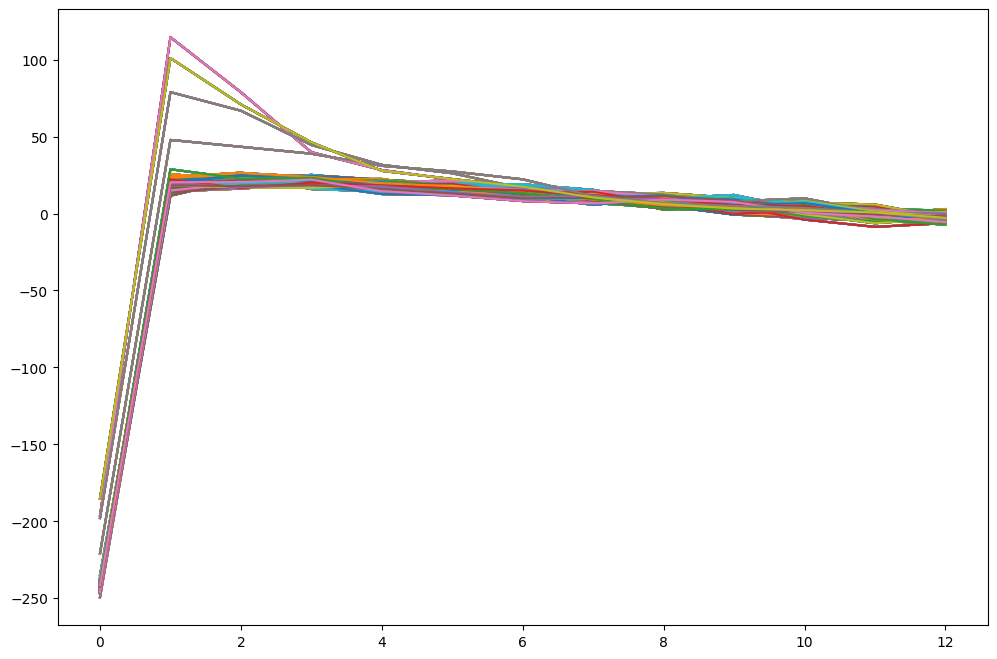

In [15]:
mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)

plt.figure(figsize=(12,8))

for i in range(mfccs.shape[0]):
    
    plt.plot(mfccs)
